# OBJETIVO DEL PROYECTO

El objetivo del presente proyecto será poner a prueba todos los conocimientos adquiridos en el Modulo 1 del curso Data Science.

Así, usando como base un dataset real de información global de videojuegos, se usaran las diferentes herramientas adquiridas para cargar información, lectura e interpretación primaria de datos, limpieza y tratamiento de datos nulos y/o duplicados, organización de datasets, creación de tablas, filtrado de información, creación e interpretración de gráficos, análisis de datos y pruebas estadísticas.

El presente proyecto se desarrollará a lo largo de 6 pasos, terminando con una conclusión general de todo el proceso, en donde se darán recomendaciones sobre como abordar la planeación de una campaña de promción de videojuegos.

El dataset aborda videojuegos desde el año 1980 hasta 2016 y se planea realizar, en base a los análisis a desarrollar, una campaña de promoción de videojuegos y consolas para el 2017.

## PASO 1. CARGA Y LECTURA DE DATOS

Lo primero será cargar las diferentes librerias necesarias para la totalidad del proyecto.

In [1]:
#Cargar librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

Se procede a cargar y leer la información general del dataset. Luego de revisar el .csv en un bloc de notas, se observa que los datos estan separados por coma (,) y el separador de numeros decimales es el punto (.)

In [3]:
#Cargar el dataset y leer su información
games = pd.read_csv('C:/Users/gusta/OneDrive/Desktop/Curso Ciencia de Datos/Sprint 6/proyecto_sprint_6/games.csv')
games.info()
print(games.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')


In [4]:
#Mostramos una primera vista general del dataset cargado y se revisa rapidamente su estructura inicial
print(games.head(20))

                                            Name Platform  Year_of_Release  \
0                                     Wii Sports      Wii           2006.0   
1                              Super Mario Bros.      NES           1985.0   
2                                 Mario Kart Wii      Wii           2008.0   
3                              Wii Sports Resort      Wii           2009.0   
4                       Pokemon Red/Pokemon Blue       GB           1996.0   
5                                         Tetris       GB           1989.0   
6                          New Super Mario Bros.       DS           2006.0   
7                                       Wii Play      Wii           2006.0   
8                      New Super Mario Bros. Wii      Wii           2009.0   
9                                      Duck Hunt      NES           1984.0   
10                                    Nintendogs       DS           2005.0   
11                                 Mario Kart DS       DS       

Se observa a primera vista que el df 'games' contiene 11 columnas, sus nombres estan en mayuscula inicial y tiene un total de 16715 entradas. Las columnas 'Name', 'Year_of_Release', 'Genre','Critic_Score', 'User_Score' y 'Rating' poseen datos ausentes. Además, luego de observar las primeras 20 filas del dataset, expone que la columna 'Year_of_Release' es de tipo 'float64' pero los años son numeros enteros, así que se convertirá esta columna a tipo 'int'. De igual forma, la columna 'User_Score' aparece como tipo 'object' y esta debe ser 'float64' al tratarse de una calififación; entonces esta debe ser transformada a 'float64'. También se observa en las filas que todos los strings (nombres, géneros, plataformas y ratings) poseen letras mayusculas. Finalmente, puede verse que el dataset no viene ordenado ni por año, calificaciones o rating.

Antes de todo lo anterior, es necesario identificar y procesar los datos ausentes y duplicados. Se convertiran a minusculas todos los nombres de juegos, generos, plataformas y rating para evitar futuros inconvenientes con los string. Todo esto se hará a partir del siguiente paso.

## PASO 2. PREPARACIÓN DE LOS DATOS

In [5]:
#Convertimos los nombres de columnas y datos de columnas de interes a minusculas 
games.columns = games.columns.str.lower().str.strip()
games['name'] = games['name'].str.lower()
games['platform'] = games['platform'].str.lower()
games['genre'] = games['genre'].str.lower()
games['rating'] = games['rating'].str.lower()

In [6]:
#Identificamos datos totalmente duplicados, unicos y ausentes
print('El número de filas completamente iguales es',games.duplicated().sum())
print()
print('Las consolas del dataset son:',games['platform'].nunique(),games['platform'].unique())
print()
print('Los generos del dataset son:',games['genre'].nunique(),games['genre'].unique())
print()
print('Los ratings del dataset son:',games['rating'].nunique(),games['rating'].unique())
filas_nulas = games[games['name'].isna()]
print()
print('Las filas con nombres ausentes son:')
print(filas_nulas)


El número de filas completamente iguales es 0

Las consolas del dataset son: 31 ['wii' 'nes' 'gb' 'ds' 'x360' 'ps3' 'ps2' 'snes' 'gba' 'ps4' '3ds' 'n64'
 'ps' 'xb' 'pc' '2600' 'psp' 'xone' 'wiiu' 'gc' 'gen' 'dc' 'psv' 'sat'
 'scd' 'ws' 'ng' 'tg16' '3do' 'gg' 'pcfx']

Los generos del dataset son: 12 ['sports' 'platform' 'racing' 'role-playing' 'puzzle' 'misc' 'shooter'
 'simulation' 'action' 'fighting' 'adventure' 'strategy' nan]

Los ratings del dataset son: 8 ['e' nan 'm' 't' 'e10+' 'k-a' 'ao' 'ec' 'rp']

Las filas con nombres ausentes son:
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      gen           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      gen           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Debido a que el nombre de un videojuego es una de las variables categóricas más importantes para poder analizarlo, primero buscamos aquellas filas con nombres ausentes, ya que un juego sin nombre es sospechoso. Son dos en total. En estas vemos que no solo les falta el nombre, sino tambien el genero, las calificaciones, rating, y fueron lanzadas para la Sega Genesis (Gen) en 1993. Ya que ambas filas poseen datos de ventas y lo ideal es poder contar con toda la información monetaria, se decide dejar estas dos filas, reemplazando tanto el nombre como el genero por 'unknown'.

In [7]:
#Reemplazamos en las 2 filas los nombres y generos ausentes por 'unknown'.
games['name'] = games['name'].fillna('unknown')
games['genre'] = games['genre'].fillna('unknown')
#Se verifica una vez más
filas_nulas = games[games['name'].isna()]
print()
print('Las filas con nombres ausentes son:')


Las filas con nombres ausentes son:


La columna 'user_score' posee datos estblecidos como tbd ('to be determined'). Esto puede indicar que no existen suficientes reseñas de ese juego como para dar una calificación, por lo que, básicamente, es un dato ausente. Para poder convertir esta columna a tipo 'float' y poder hacer calculos, se transformaran los tbd en NaN.

In [8]:
#Convertimos los tbd en NaN
games['user_score'] = pd.to_numeric(games['user_score'],errors='coerce')

Hay un total de 269 registros de videojuegos con el año de lanzamiento como ausente ('NaN'). Varios de estos juegos se repiten en consolas que si poseen información del año de lanzamiento. Así, se reemplazaran los datos de años ausentes agrupando por juego y usando el año de lanzamiento mínimo.

In [9]:
#Corroboramos los registros sin información de año de lanzamiento
print('El número de videojuegos sin registro de año es:',games['year_of_release'].isna().sum())
print()
games['year_of_release'] = games['year_of_release'].fillna(games.groupby('name')['year_of_release'].transform('min'))
#Corroboramos que los registros esten transformados
print('El número de videojuegos sin registro de año, luego de la limpieza, es:',games['year_of_release'].isna().sum())
print()
juegos_huerfanos = games[games['year_of_release'].isna()]
print('los juegos sin año de lanzamiento son:',juegos_huerfanos)

El número de videojuegos sin registro de año es: 269

El número de videojuegos sin registro de año, luego de la limpieza, es: 146

los juegos sin año de lanzamiento son:                                            name platform  year_of_release  \
475                  wwe smackdown vs. raw 2006      ps2              NaN   
627                                   rock band     x360              NaN   
657    frogger's adventures: temple of the frog      gba              NaN   
805                                   rock band      wii              NaN   
1142                                  rock band      ps3              NaN   
...                                         ...      ...              ...   
16277           homeworld remastered collection       pc              NaN   
16288                                    shorts       ds              NaN   
16348              agarest senki: re-appearance      ps3              NaN   
16458               hakuouki: shinsengumi kitan      ps3    

Luego de la limpieza, el registro de videojuegos huerfanos de año de lanzamiento se reduce a 146. Pueden existir varias causas para esto; por ejemplo, juegos que al final fueron cancelados y no fueron distibuidos. Otra posible razón puede ser fallas al extraer los datos de las diferentes paginas web; al buscar algunos juegos de muestra en la web, estos registran fechas de lanzamiento, pero en el dataset continuan sin registro de año; así, es probable que hayan habido desconexiones al cruzar diferentes bases de datos.

Por lo anterior, se decide rellenar estos datos de año ausente con un valor bandera fuera de rango (9999) que permita identificar estos juegos y poder realizar la transformación correcta de los datos.

In [10]:
#Rellenamos los datos ausentes y transformamos a entero
games['year_of_release'] = games['year_of_release'].fillna(9999)
games['year_of_release'] = games['year_of_release'].astype('int')

Tanto en la columna 'critic_score' como en 'user_score' se optará por dejar los valores NaN. No se reemplazaran por ceros (0) ya que esto puede influenciar calculos estadisticos más adelante, además que un cero significa que es el peor juego de la historia. NaN solo significa que este dato no esta disponible y los métodos estadísticos y matemáticos pueden ignorar estos NaN perfectamente para mantener los resultados más reales. Que casi la mitad de los juegos no tengan score, puede significar que estos son muy antiguos (antes de las creacion de plataformas de calificación), son pequeños o de nicho, es decir, no tienen mucha prensa o no son conocidos. Finalmente, no se rellenaran con datos como media o mediana, ya que eso puede hacer que juegos con mala calificación en la vida real tengan buenas puntuaciones y visceversa. 

Finalmente, la columna 'rating', al ser tipo 'object', permite que facilmente los valores ausentes puedan ser reemplazados por 'unknown'.

In [11]:
#Rellenamos los datos ausen
games['rating'] = games['rating'].fillna('unknown')

Se procede a verificar que los datos se encuentren en su tipo correcto y no existan registros ausentes en el dataset (a excepción de las columnas de score).

In [12]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Se creará una nueva colummna en el dataset, la cual corresponderá a las ventas totales por videojuego, sumando las ventas en todas las regiones.

In [13]:
#Creamos una nueva columna con la sumatoria de todas las ventas por región
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
#Reordenamos las columnas para incluir la nueva
orden_columnas = ['name','platform','year_of_release','genre','na_sales','eu_sales','jp_sales','other_sales','total_sales','critic_score','user_score','rating']
games = games[orden_columnas]
#Se corrobora la creación de la nueva columna y el nuevo orden
games.info()
print()
print(games)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   total_sales      16715 non-null  float64
 9   critic_score     8137 non-null   float64
 10  user_score       7590 non-null   float64
 11  rating           16715 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB

                                name platform  year_of_release         genre  \
0                         wii sports      wii             2006        sports   
1                  super

Ahora que se ha aplicado la gestión de duplicados y datos ausentes al dataset y se han calculado las ventas totales, la información esta limpia y lista para los diferentes análisis.

## PASO 3. ANÁLISIS DE DATOS

El primer análisis de datos será observar como varía la producción de videojuegos por año.

Los años de lanzamiento incluidos en el dataset son: 38 [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 9999]

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      42
1992      43
1993      62
1994     122
1995     219
1996     263
1997     290
1998     379
1999     339
2000     351
2001     486
2002     845
2003     783
2004     764
2005     948
2006    1018
2007    1202
2008    1441
2009    1430
2010    1269
2011    1153
2012     662
2013     548
2014     581
2015     606
2016     502
9999     146
Name: year_of_release, dtype: int64



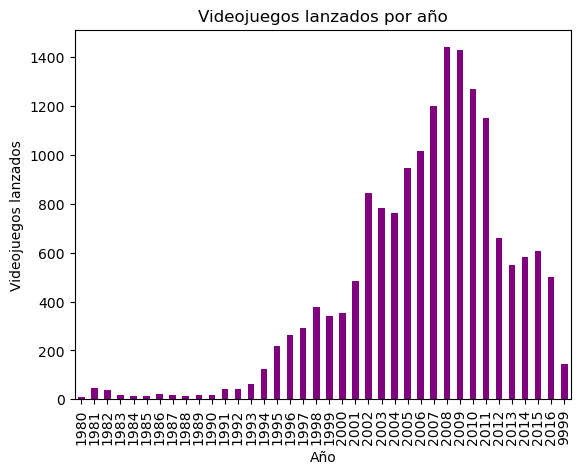

In [14]:
#Organizamos los videojuegos por año de lanzmaiento, del más antiguo al más nuevo
games = games.sort_values(by='year_of_release')
print('Los años de lanzamiento incluidos en el dataset son:',games['year_of_release'].nunique(),games['year_of_release'].unique())
#Agrupamos por año para saber el número de videojuegos lanzados por año
print()
games_by_year = games.groupby('year_of_release')['year_of_release'].size()
print(games_by_year)
print()
#Creamos un gráfico de barras que ilustre de mejor manera lo observado en la lista
games_by_year.plot(kind='bar',title='Videojuegos lanzados por año',xlabel='Año',ylabel='Videojuegos lanzados',color='purple')
plt.show()

En base al diagrama de barras, pueden observarse 4 grandes periodos. 

Entre 1980 y 1994 los videojuegos lanzados no superaban los 200; podría decirse que fue un periodo de iniciación y las muestras de videojuegos son pequeñas (esto puede explicar el por qué la gran mayoría no poseen puntuaciones). 

Entre 1995 y 2005 está el segundo periodo; el lanzamiento de videojuegos se da por centenares y coincide con el lanzamiento de consolas como la xbox, ps2, nintendo 64; es decir, la llegada de los 32 y 64 bits. El volumen de datos en este periodo ya es robusto y se da inicio a la competencia entre consolas. 

El tercer momento es entre 2006 y 2011; puede decirse que es la epoca dorada de los videojuegos y de la famosa 'guerra de consolas'. Coincide con el lanzamiento de plataformas como la xbox 360 y la ps3 y es el periodo con mayor cantidad de datos en el dataset. Culaquier valoración estadística puede estar respaldada por la cantidad masiva de datos de ventas y hasta más de mil lanzamientos por año. 

Finalmente, el periodo entre 2012 y 2016 muestra una caída en el lanzamiento de videojuegos. Esta caida sin embargo no significa que se hayan dejado de vender o lanzar videojuegos; coincide con la aparición de juegos digitales y plataformas como Steam o XboxLive y, por tanto, la migración a la compra de juegos digitales. Cómo el dataset recopila principalmente la venta de juegos físicos, es entonces normal que se presente esta caida. 

Además, puede observarse el año '9999', el cual recopila aquellos videojuegos herfanos de registro de año de lanzamiento en este dataset; el volumen de estos es equiparable al del año 1994.

In [15]:
#Agrupamos el dataset por plataformas y sus ventas totales

sales_by_platform = games.groupby('platform')['total_sales'].sum()
print(sales_by_platform.sort_values(ascending=False))


platform
ps2     1255.77
x360     971.42
ps3      939.65
wii      907.51
ds       806.12
ps       730.86
gba      317.85
ps4      314.14
psp      294.05
pc       259.52
3ds      259.00
xb       257.74
gb       255.46
nes      251.05
n64      218.68
snes     200.04
gc       198.93
xone     159.32
2600      96.98
wiiu      82.19
psv       54.07
sat       33.59
gen       30.77
dc        15.95
scd        1.86
ng         1.44
ws         1.42
tg16       0.16
3do        0.10
gg         0.04
pcfx       0.03
Name: total_sales, dtype: float64


En base a la lista anterior, se toman las primeras seis consolas como aquellas de mayores ventas totales, basados en que superan historicamente los 500 millones de dolares. Se crea una tabla dinámica que permita ver entonces el comportamiento de estas 6 consolas año a año.

In [16]:
#Filtramos el dataset 
consolas_populares = ['ps2','x360','ps3','wii','ds','ps']
df_consolas_populares = games[games['platform'].isin(consolas_populares)]
#Construimos una tabla dinámica
tabla_consolas_top= df_consolas_populares.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')
print(tabla_consolas_top)

platform             ds      ps     ps2     ps3     wii    x360
year_of_release                                                
1985               0.02     NaN     NaN     NaN     NaN     NaN
1991                NaN     NaN     NaN    0.48     NaN     NaN
1994                NaN    6.03     NaN     NaN     NaN     NaN
1995                NaN   35.96     NaN     NaN     NaN     NaN
1996                NaN   94.70     NaN     NaN     NaN     NaN
1997                NaN  136.17    0.95     NaN     NaN     NaN
1998                NaN  169.49     NaN     NaN     NaN     NaN
1999                NaN  144.53     NaN     NaN     NaN     NaN
2000                NaN   96.37   39.17     NaN     NaN     NaN
2001                NaN   35.59  166.43     NaN     NaN     NaN
2002                NaN    6.67  208.36     NaN     NaN     NaN
2003                NaN    2.07  193.05     NaN     NaN     NaN
2004              17.27     NaN  211.81     NaN     NaN     NaN
2005             130.14     NaN  160.91 

El valor bandera al final de la tabla (9999) corresponde a las ventas totales por consolas populares de aquellos juegos a los cuales no se les pudo rescatar información de su año de lanzamiento. 

También pueden obervarse tres anomalías cronológicas. La ds, la ps2 y la ps3 tienen datos de ventas en años en donde aún no existian estas plataformas; esto podría explicarse en pasos anteriores en este proyecto en donde, en base al nombre del juego, se rellenaron datos ausentes de año de lanzamiento y esto pudo hacer que información financiera se viera arrastrada a esos años. 

La tabla dinámica entonces se filtrará para eliminar los años previos a 1994 y el unico dato anomalo (de la ps2 en 1997), al ser tan pequeño (<1) en comparación al resto de información, solo se ignorará. Además, ya que en este punto solo se esta analizando el ciclo de vida y popularidad de una consola, tambien se filtrara la tabla para eliminar el año bandera. Se procede a graficar el comportamiento de la tabla dinámica para mejor observación de patrones.

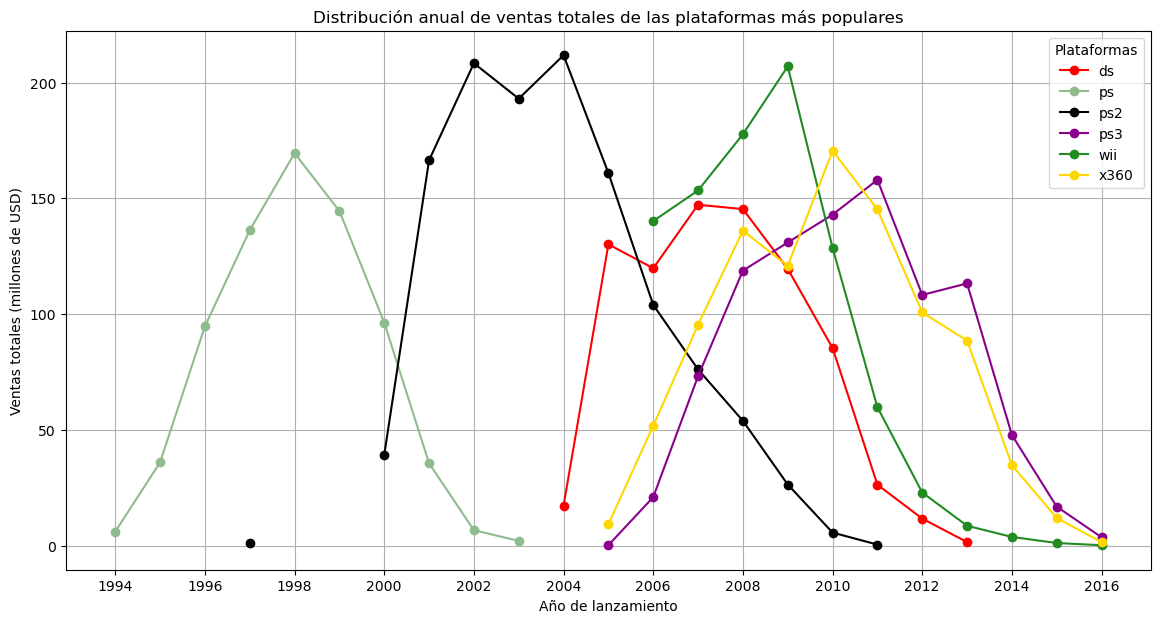

In [17]:
#Filtramos la tabla dinámica para eliminar años previos a 1994 y el año bandera
df_consolas_populares = games[(games['platform'].isin(consolas_populares))&(games['year_of_release']>=1994)&(games['year_of_release']<=2016)]
#Actualizamos la tabla dinámica
tabla_consolas_top= df_consolas_populares.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')
#Graficamos la tabla nueva
colores_plataformas = ['red','darkseagreen','black','darkmagenta','forestgreen','gold']
tabla_consolas_top.plot(kind='line',title='Distribución anual de ventas totales de las plataformas más populares',xlabel='Año de lanzamiento',ylabel='Ventas totales (millones de USD)',grid=True,marker='o',figsize=(14,7),color=colores_plataformas)
plt.xticks(np.arange(1994, 2017, 2))
plt.legend(title='Plataformas')
plt.show()

Al observar la gráfica, es posible concluir que la esperanza de vida de una consola esta entre 9 y 11 años. Tomando como referencia los años desde 2004 (inicio de la epoca dorada de los videojuegos), ya que es de donde más datos y tendencias podemos tomar, todas las consolas nacen, llegan a un pico de popularidad y luego mueren. Lo anterior debido al relevo generacional; es decir, la llegada de software más potente hace que las consolas previas inicien un declive en sus ventas hasta su obsolencia completa. 

Es posible observar que, generalmente, cada consola alcanza su pico de exito entre sus primeros 3 y 5 años de existencia. 

Sumado a lo anterior, la gráfica tambien ilustra que, a partir de 2004 y la creación de software potente, generalmente las nuevas plataformas tardan en aparecer entre uno y dos años entre si, mientras que las consolas previas permanecen por otros 5 a 7 años antes de desaparecer.

Con todo lo anterior, se llega a la conclusión de que es pertinente tomar datos en el periodo 2004 a 2016. Con el alto volumen de información de ventas, puntuaciones y ratings, este rango de tiempo permite analizar y modelar el comportamiento del ciclo de vida de las consolas de manera muy acertada. Se toma en cuenta también el periodo de declive de las consolas (hasta 2016), ya que es importante predecir como futuras consolas (a partir de 2017) se comportaran a partir de su 5to y 6to año. 

Sumado a lo anterior, se decide no tomar la informacion de los videojuegos que no poseen un año de lanzamiento (9999). Si bien estos suman un total de 27.2 millones de dolares en ventas globales para las 6 consolas más populares y no es un valor menor, el objetivo de este proyecto incluye realizar modelos y análisis que permitan predecir comportamientos posteriores a 2016. Al tratarse de un objetivo que requiere de temporalidad, aquellos juegos sin año carecen de una coordenada en el tiempo y, por tanto, son datos que no aportan a las proyecciones futuras y solo generarian ruido y distorsion estadistica. Además, al representar una fracción pequeña del volumen histórico de estas consolas, su exclusión no altera las tendencias generales de ventas.

platform
x360    966.61
ps3     934.71
wii     903.31
ds      804.26
ps2     639.20
ps4     314.14
psp     293.57
3ds     258.51
pc      181.23
xone    159.32
xb      125.83
gba     121.30
wiiu     82.19
gc       68.55
psv      53.81
n64       0.33
dc        0.06
Name: total_sales, dtype: float64
platform           3ds    dc      ds    gba     gc   n64     pc     ps2  \
year_of_release                                                           
2004               NaN   NaN   17.27  77.91  28.82  0.33  10.39  211.81   
2005               NaN   NaN  130.14  34.53  27.91   NaN   4.38  160.91   
2006               NaN   NaN  119.81   5.46  11.55   NaN   2.85  103.99   
2007               NaN  0.02  147.23   3.40   0.27   NaN   9.28   76.10   
2008               NaN  0.04  145.36    NaN    NaN   NaN  12.46   53.90   
2009               NaN   NaN  119.56    NaN    NaN   NaN  17.05   26.40   
2010              0.30   NaN   85.35    NaN    NaN   NaN  26.15    5.64   
2011             63.20   Na

<Axes: title={'center': 'Distribución anual de ventas totales de las plataformas modernas más populares'}, xlabel='Año de lanzamiento', ylabel='Ventas totales (millones de USD)'>

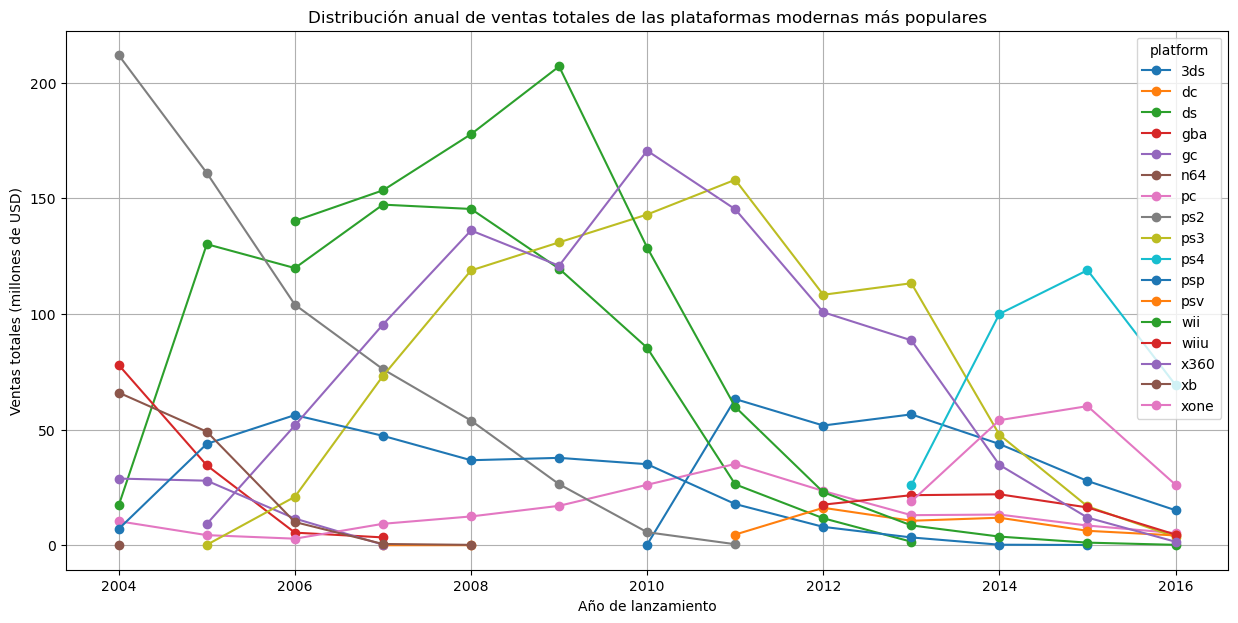

In [18]:
#Creamos un dataset con todas las consolas y juegos entre 2004 y 2016
df_juegos_modernos = games[(games['year_of_release']>=2004)&(games['year_of_release']<=2016)]
#Corroboramos de nuevo la lista de plataformas lideres en ventas para el periodo tomado
sales_by_modern_platform = df_juegos_modernos.groupby('platform')['total_sales'].sum()
print(sales_by_modern_platform.sort_values(ascending=False))
#Miramos una tabla dinámica que muestre los comportamientos de las consolas y sus ventas
tabla_consolas_modernas= df_juegos_modernos.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')
print(tabla_consolas_modernas)
#Creamos un gráfico de lineas de todas las consolas
tabla_consolas_modernas.plot(kind='line',title='Distribución anual de ventas totales de las plataformas modernas más populares',xlabel='Año de lanzamiento',ylabel='Ventas totales (millones de USD)',grid=True,marker='o',figsize=(15,7))

De las tablas y gráfico anterior se puede decir lo siguiente: Las consolas lideres en ventas entre 2004 y 2016 siguen siendo las mismas observadas en pasos anteriores, a excepción de la ps2 (esto es debido a que su exito en ventas fue entre el 2000 y 2003, por eso su registro de ventas se ve afectado, pero sigue siendo la consola con más ventas de la historia). No bstante, puede ilustrarse que para el 2016, las consolas lideres en ventas estan en declive; esto es porque ya estan cumpliendo su ciclo de vida.

Plataformas como la wiiu y la psv si bien tuvieron un leve crecimiento, no tuvieron exito realmente y se observa que su comportamiento de ventas es muy suave (realmente fueron un fracaso). 

La Nintendo 3DS tuvo un comportamiento estable 3 años pero luego empezó un rapido declive; para 2016 los juegos moviles de celular entraron en aunge y esto pudo ayudar a su rapida caida en ventas.

En este dataset hay que anotar, luego de observar la tabla dinámica y la gráfica, que hay dos consolas que iniciaron su registro de ventas en 2013: la ps4 y la xbox one. Ya que el dataset solo va hasta 2016, este no alcanza a registrar el comportamiento posterior, pero ambas consolas se encuentran en su etapa temprana de crecimiento.

Finalmente, la pc es una plataforma particular ya que no presenta un ciclo de vida similar a las demás. Esto es debido a que la pc siempre será necesaria y, además, no tiene una "fecha de vencimiento" porque todos sus componentes se actualizan permanentemente.

Comforme a lo anterior, es posible deducir que de las plataformas incluidas en el datsset, aquellas potencialmente rentables y a considerar en modelos predictivos a 2017 son la ps4, la xbox one y la pc.

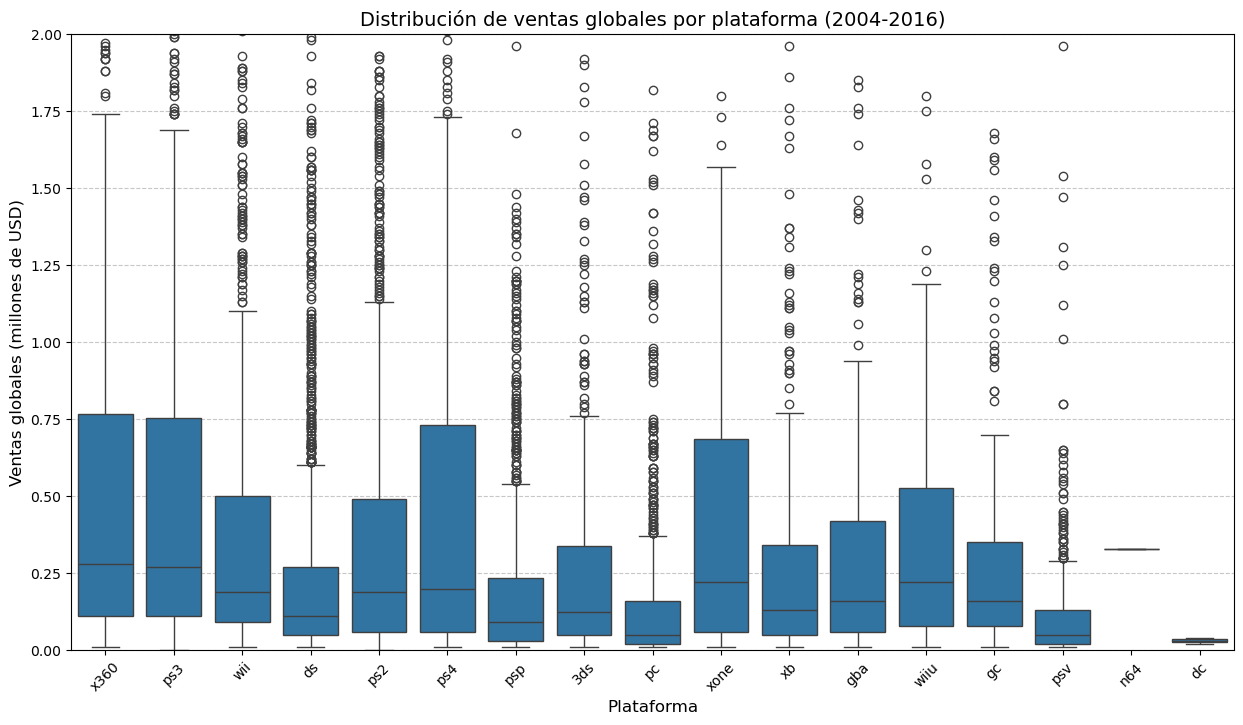

In [19]:
#Ordenamos las plataformas, en secuencia de mayores a menores ventas, para el diagrama
orden_plataformas = sales_by_modern_platform.sort_values(ascending=False).index
#Creamos los diagramas de caja
plt.figure(figsize=(15,8))
sns.boxplot(data=df_juegos_modernos,x='platform', y='total_sales', order=orden_plataformas)
plt.title('Distribución de ventas globales por plataforma (2004-2016)',fontsize=14)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas globales (millones de USD)',fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
#Limitamos el eje Y del gráfico. Esto porque los juegos con mas de 20 millones de copias vendidas pueden alterar la visualización
#Luego de varias iteraciones, se límita el eje Y entre 0 y 2
plt.ylim(0,2)
plt.show()


Del diagrama anterior se puede decir que:

Las diferencias en ventas entre plataformas son bastante significativas. En las consolas x360, ps3, ps4 y xone se puede observar que sus cajas son muchos mas grandes; es decir, el 50% central de sus juegos distribuye sus ventas en rangos mucho más altos. Podría decirse que un juego en estas plataformas tendrá mayor probabilidad de vender mas copias que en otros. Además, visualmente, esto coincide con la elección anterior de plataformas rentables a futuro.

Consolas portatiles como las psv o el psp en cambio, tienen una inmensa mayoria de juegos que se quedan en ventas bajas, lo que demuestra que su mercado actual va dirigido a usuarios de nicho.

Se puede observar que las lineas en todas las cajas (la mediana) se encuentran por debajo de los 0.3 millones. Esto puede ser indicativo de que, estadísticamente, la gran mayoría de los juegos que se desarrollan no se vuelven ricos ni famosos, sino que tienen ventas modestas. Sin embargo, respecto al promedio de ventas, este se ve afectado por el gran número de valores atípicos, los cuales representan grandes exitos para cada plataforma (ej:WiiSports). Unos pocos exitos mundiales jalan el promedio general hacia arriba, aunque el juego promedio de la consola venda mucho menos.

Finalmente, puede decirse que los exitos globales en ventas (datos atipicos), son muchos más para las consolas de la izquierda que para las de la derecha (ej:la WiiU tuvo pocos exitos globales).

Para analizar como las criticas de ususarios y profesionales afectan las ventas de una plataforma popular, se escogerá como ejemplo la xbox 360. Esto debido a que todo su ciclo de vida puede ser perfectamente observado en el periodo 2004-2016. Además, aunque podría escogerse de ejemplo bajo el mismo parametro la ps3, la elección también se ve afectada por un tema de gusto personal del analista.

Se creará un dataset solo con la información de la consola xbox 360 y se agregará una columna adicional que muestre que tan grande es la brecha entre la critica de usuarios y profesionales. Esto debido a que muchas veces un juego puede tener buena calificación profesional pero, ya que los ususarios pueden ser más suceptibles a sesgos emocionales, tener una muy baja calififcación de los ususarios. La diferencia entre estas dos calificaciones permitirá mostrar cuales juegos son exitos comerciales y cuales fueron "victimas" de fenómenos mediaticos.

                                                    name platform  \
5969                                         nba live 06     x360   
7020                                             nba 2k6     x360   
5779                             tiger woods pga tour 06     x360   
7644                                       ridge racer 6     x360   
6342                                                 gun     x360   
...                                                  ...      ...   
4283                                     lego the hobbit     x360   
3139                                            wwe 2k15     x360   
12641  adventure time: the secret of the nameless kin...     x360   
10399               pac-man and the ghostly adventures 2     x360   
8426                                          nascar '14     x360   

       year_of_release      genre  na_sales  eu_sales  jp_sales  other_sales  \
5969              2005     sports      0.27      0.00      0.00         0.02   
7020       

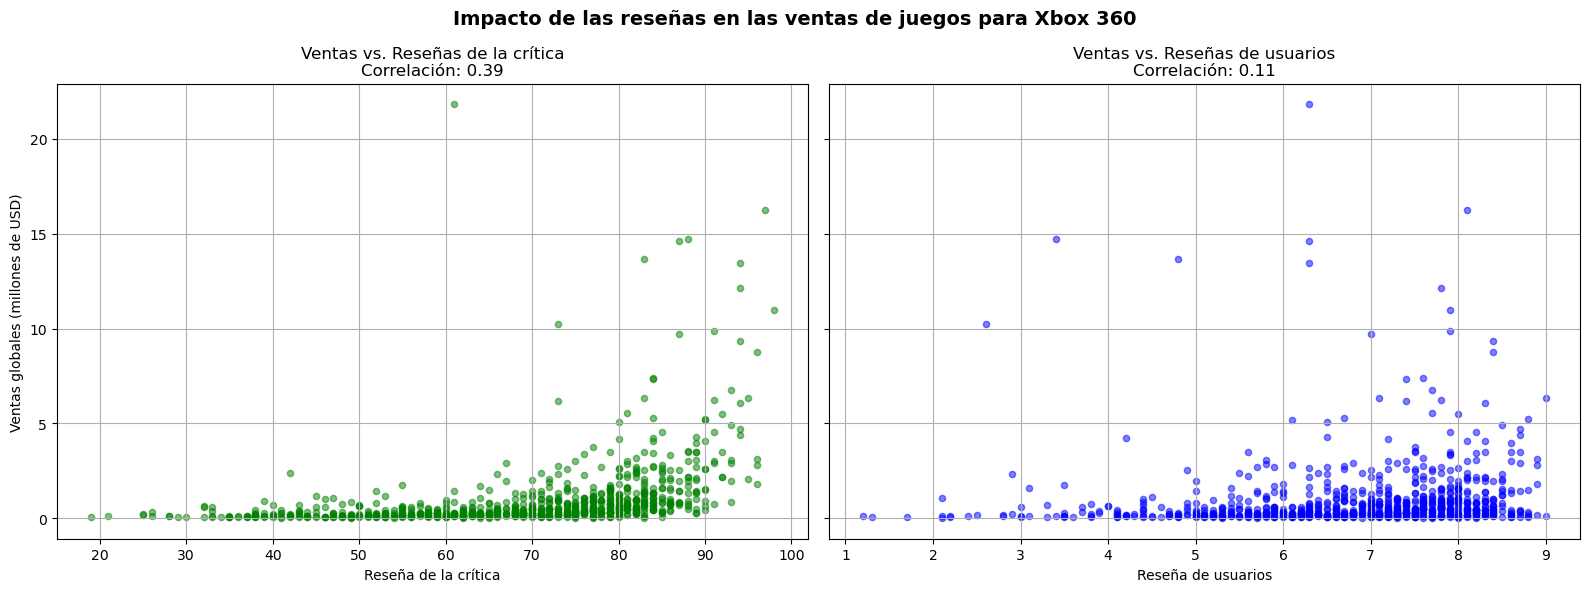

In [20]:
#Creamos el dataset solo con información de la xbox 360
xbox_360_games = df_juegos_modernos[df_juegos_modernos['platform']=='x360'].copy()
#Agregamos la nueva columna y reordenamos las columnas
xbox_360_games['score_gap'] = xbox_360_games['critic_score']-(xbox_360_games['user_score']*10)
nuevo_orden_columnas = ['name','platform','year_of_release','genre','na_sales','eu_sales','jp_sales','other_sales','total_sales','critic_score','user_score','score_gap','rating']
xbox_360_games = xbox_360_games[nuevo_orden_columnas]
#Para calcular los coeficientes de correlación correctamente, se usaran aquellas filas que cuenten con ambos score
xbox_360_games_limpio = xbox_360_games.dropna(subset=['critic_score','user_score']).copy()
print(xbox_360_games_limpio)
#Calculamos los coeficientes de correlación tanto para las criticas de expertos como de los ususarios
correlacion_critica = xbox_360_games_limpio['critic_score'].corr(xbox_360_games_limpio['total_sales'])
correlacion_usuarios = xbox_360_games_limpio['user_score'].corr(xbox_360_games_limpio['total_sales'])
print()
print('El coeficiente de correlación entre las reseñas profesionales y las ventas es:',correlacion_critica)
print('El coeficiente de correlación entre las reseñas de usuarios y las ventas es:',correlacion_usuarios)
print()
#Creamos ahora los gráficos de dispersión para cada tipo de critica
fig,(ax1, ax2) = plt.subplots(1,2,figsize=(16,6),sharey=True)
xbox_360_games_limpio.plot(kind='scatter',x='critic_score',y='total_sales',alpha=0.5,color='green',grid=True,ax=ax1)
ax1.set_title(f'Ventas vs. Reseñas de la crítica\nCorrelación: {correlacion_critica:.2f}')
ax1.set_xlabel('Reseña de la crítica')
ax1.set_ylabel('Ventas globales (millones de USD)')
xbox_360_games_limpio.plot(kind='scatter',x='user_score',y='total_sales',alpha=0.5,color='blue',grid=True,ax=ax2)
ax2.set_title(f'Ventas vs. Reseñas de usuarios\nCorrelación: {correlacion_usuarios:.2f}')
ax2.set_xlabel('Reseña de usuarios')
ax2.set_ylabel('')
plt.suptitle('Impacto de las reseñas en las ventas de juegos para Xbox 360',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

El gráfico de dispersión es muy diciente. Ambas correlaciones son positivas, es decir, existe una tendencia al incremento relacionado entre mayores puntajes y un mayor volumen de ventas. Sin embargo, la correlación entre las reseñas de la crítica y las ventas totales es notablemente superior a la de las reseñas de los usuarios. De hecho, mientras que 0.39 indica una correlación positiva moderada, 0.11 es una correlación "positiva" pero estadisticamente insignificante (una correlación mucho más cercana a cero).

Puede afirmarse que las reseñas de los criticos son mas confiables que las de los usuarios, estadisticamente hablando, por lo siguiente: primero, se reafirma que los puntajes de ususarios estan sujetos a suceptibilidades emocionales; prueba de ello es que hay juegos con calificaciones menores a 5 pero con un buen numero de ventas. Segundo, si bien en ambos gráficos se expone que a mayores calificaciones se observan picos de ventas más altos, el gráfico de la crítica profesional (izquierdo) exhibe una tendencia más clara: a partir de una puntuación aproximada de 72, los datos comienzan a mostrar magnitudes de ventas superiores. Esta tendencia de dispersión no se repite en el gráfico de usuarios (derecho).

En conclusión, los datos demuestran que una alta puntuación de la crítica especializada se asocia con una mayor probabilidad de éxito comercial, mostrando una asociación más grande. Por el contrario, las valoraciones de los usuarios en internet muestran una asociación insignificante, lo que evidencia que las buenas o malas calificaciones no están directamente vinculadas al comportamiento del mercado de un videojuego.

Como nota adicional, sería interesante para futuros estudios y análisis comparar estas correlaciones y dispersiones con otras consolas, para concluir con más fuerza si lo anterior aplica a todo el mercado sin importar la consola o es un comportamiento único de la Xbox360.

In [21]:
#Creamos una tabla dinámica de juegos multiplataforma
tabla_juegos_modernos = df_juegos_modernos.pivot_table(index='name',columns='platform',values='total_sales')
juegos_multiplataforma = tabla_juegos_modernos.notna().sum(axis=1)>=2
tabla_multiplataforma = tabla_juegos_modernos[juegos_multiplataforma]
print(f"Total de juegos multiplataforma encontrados: {len(tabla_multiplataforma)}")
print(tabla_multiplataforma)

Total de juegos multiplataforma encontrados: 2181
platform                                             3ds  dc    ds  gba  gc  \
name                                                                          
 frozen: olaf's quest                               0.59 NaN  0.51  NaN NaN   
007: quantum of solace                               NaN NaN  0.13  NaN NaN   
11eyes: crossover                                    NaN NaN   NaN  NaN NaN   
187: ride or die                                     NaN NaN   NaN  NaN NaN   
2 in 1 combo pack: sonic heroes / super monkey ...   NaN NaN   NaN  NaN NaN   
...                                                  ...  ..   ...  ...  ..   
zoo hospital                                         NaN NaN  0.03  NaN NaN   
zoo tycoon (2013)                                    NaN NaN   NaN  NaN NaN   
zumba fitness                                        NaN NaN   NaN  NaN NaN   
zumba fitness core                                   NaN NaN   NaN  NaN NaN   
zu

Comparar los juegos multiplataforma puede dar la siguiente conclusión: Si tomamos como ejemplo el videojuego zumba fitness, puede observarse que su plataforma de venta exitosa fue la nintendo wii, mientras que su mercado para la xbox 360 o la ps3 estuvo muy por debajo. Lo anterior quiere decir que si bien un juego puede ser un exito en ventas, las criticas de los expertos no son el unico factor que influye en su mercado, también un mismo juego, con la misma calificación de la crítica, vende diferente solo por la base de usuarios instalada de la consola. Es normal que ciertos juegos y/o generos esten mejor referenciados para ser jugados en ciertas consolas especificas.

                  sum      mean  count
genre                                 
action        1295.13  0.474754   2728
sports         922.16  0.613138   1504
shooter        811.10  0.869346    933
misc           648.96  0.443279   1464
role-playing   605.43  0.535779   1130
racing         403.30  0.564846    714
platform       350.28  0.716319    489
simulation     280.99  0.416899    674
fighting       225.61  0.453032    498
adventure      158.45  0.143524   1104
puzzle         119.33  0.278808    428
strategy        86.19  0.188188    458


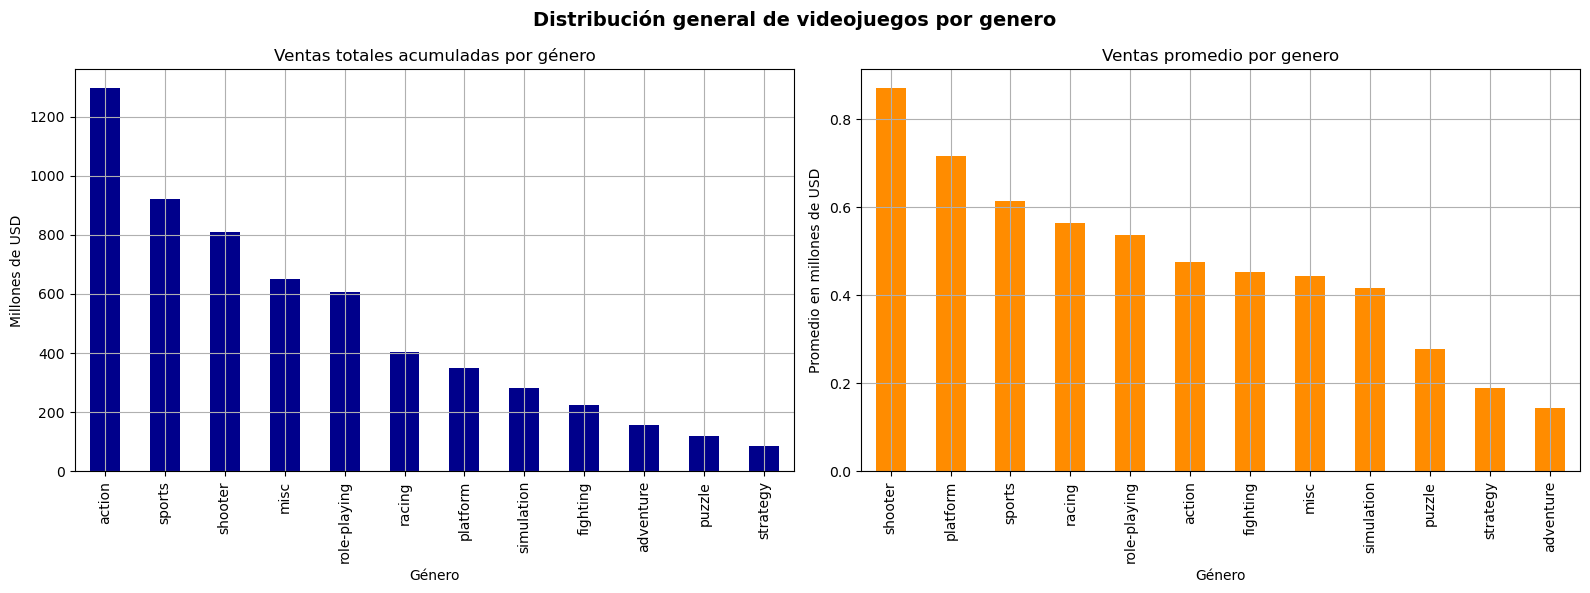

In [22]:
#Generamos una lista de generos mostrando cuales han sido sus ventas totales y promedio
analisis_por_genero = df_juegos_modernos.groupby('genre')['total_sales'].agg(['sum','mean','count']).sort_values(by='sum',ascending=False)
print(analisis_por_genero)
#Creamos graficos que ayuden a visualizar mejor este comportamiento
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
analisis_por_genero['sum'].plot(kind='bar',color='darkblue',ax=ax1,grid=True)
ax1.set_title('Ventas totales acumuladas por género')
ax1.set_ylabel('Millones de USD')
ax1.set_xlabel('Género')
analisis_por_genero.sort_values(by='mean',ascending=False)['mean'].plot(kind='bar',color='darkorange',ax=ax2,grid=True)
ax2.set_title('Ventas promedio por genero')
ax2.set_ylabel('Promedio en millones de USD')
ax2.set_xlabel('Género')
plt.suptitle('Distribución general de videojuegos por genero',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

El análisis anterior muestra lo siguiente: Que un genero de videojuegos genere más ventas totales no significa que el juego promedio de este genero sea muy vendido. Ciertos exitos globales pertenecientes a un genero pueden disparar las ventas totales generales. A manera de ejemplo, el genero 'action', si bien es el que más ventas globales posee, en promedio un juego de acción se vende menos que un juego 'shooter'. Así mismo, aunque el genero 'platform' haya generado menos de 400 millones de USD en ventas acumuladas, en promedio estos se venden mejor que los juegos de acción. Así, es correcto afirmar que el genero más rentable en la epoca de análisis (2004-2016) ha sido el genero 'shooter'; segundo en ventas acumuladas y sus juegos se venden en promedio mucho mejor. Además, respecto a los generos rentables en general, estos poseen juegos a los cuales se les hacen enormes campañas de marketing y de expectativa, mencionando también que dependen fuertemente de franquicias masivas (por ejemplo PES, FIFA o Call of Duty).

También es posible notar que el lanzar una gran cantidad de juegos de cierto genero no hacen que este sea rentable o atractivo necesariamente. De la tabla anterior se observa que en el periodo de análisis, generos como 'misc', 'role playing' y 'adventure' lanzaron más juegos que el genero 'shooter'; aún así, como se observa en la gráfica, este último es el que mejor domina el mercado. Además, el genero 'action' fue aquel que más juegos produjo durante los 12 años de análisis y aún así no es aquel con mayores ventas promedio (aunque su gran cantidad de lanzamientos también influye en el alza de sus ventas acumuladas). Puede decirse que es un genero saturado de oferta.

Hay 3 generos con ventas bajas tanto acumuladas como en promedio: 'puzzle', 'strategy' y 'adventure'. Que estos 3 generos sean en general los de menor rentabilidad y atractivo puede deberse a que son generos con mecánicas sencillas, de ritmo lento y de nicho; mencionando también que, generalmente, no requieren de consolas potentes para ser jugados y por tanto sus ventas en formato físico para consolas suelen ser bajas.

Durante los análisis anteriores se ha entrado a fondo en los comportamientos del mercado por tipo de consola, genero o critica. Sin embargo, aún no se analíza como varía el mercado entre las regiones más fuertes de ventas. Esto entonces se verá abordado en el siguiente paso.

## PASO 4. ANÁLISIS POR REGIÓN

year_of_release
2004    222.94
2005    243.76
2006    265.61
2007    310.59
2008    353.69
2009    335.88
2010    303.39
2011    240.29
2012    155.51
2013    153.73
2014    132.27
2015    106.86
2016     44.93
Name: na_sales, dtype: float64
platform
x360    599.15
wii     494.01
ps3     391.60
ds      381.38
ps2     297.66
psp     109.09
ps4     108.74
xone     93.12
xb       91.76
3ds      83.11
gba      71.89
pc       49.25
gc       48.12
wiiu     38.10
psv      12.47
dc        0.00
n64       0.00
Name: na_sales, dtype: float64

                                 name platform  year_of_release  na_sales
6263    final fantasy x international      ps2             2004      0.00
7544     pitfall: the lost expedition      ps2             2004      0.10
6942      karaoke revolution volume 2      ps2             2004      0.11
6896          shadow hearts: covenant      ps2             2004      0.12
6282                      athens 2004      ps2             2004      0.13
...               

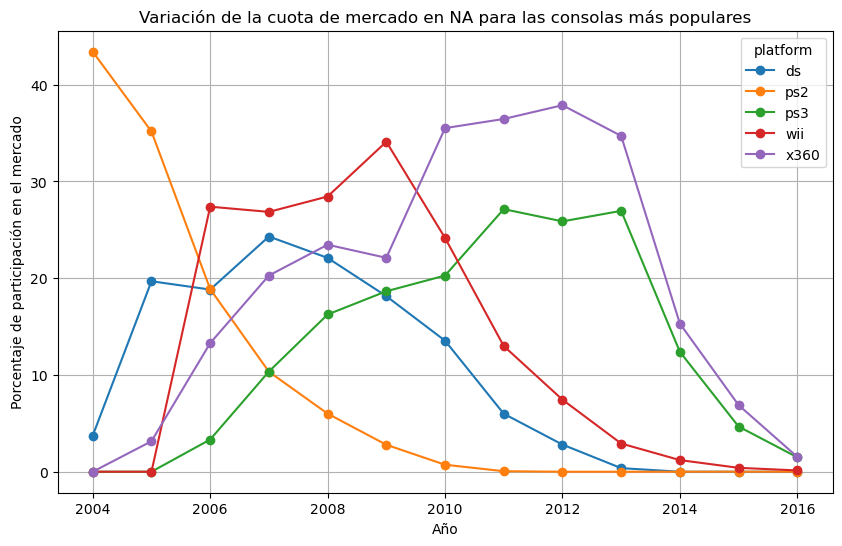

In [23]:
#Agrupamos por año y luego obtenemos la sumatoria de ventas totales para cada año en NA
ventas_anuales_na = df_juegos_modernos.groupby('year_of_release')['na_sales'].sum()
print(ventas_anuales_na)
#Agrupamos por consola y analizamos las ventas en NA para determinar las 5 consolas populares
ventas_na_consolas = df_juegos_modernos.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
print(ventas_na_consolas)
print()
#Creamos un dataset de las 5 plataformas mas populares en NA
lista_populares_na = ['x360','wii','ps3','ds','ps2']
filas_condicion_na = df_juegos_modernos['platform'].isin(lista_populares_na)
columnas_interes_na = ['name','platform','year_of_release','na_sales']
consolas_populares_na = df_juegos_modernos.loc[filas_condicion_na,columnas_interes_na]
print(consolas_populares_na)
print()
#Creamos una tabla dinámica que muestre por año la variación de la cuota de mercado de cada consola popular en NA
ventas_ano_consola_na = consolas_populares_na.pivot_table(index='year_of_release',columns='platform',values='na_sales',aggfunc='sum').fillna(0)
cuota_mercado_na = ventas_ano_consola_na.div(ventas_anuales_na,axis=0)*100
print(cuota_mercado_na)
#Gráficamos la variación año a año de la participación en el mercado para cada consola popular
cuota_mercado_na.plot(title='Variación de la cuota de mercado en NA para las consolas más populares',xlabel='Año',ylabel='Porcentaje de participación en el mercado',kind='line',grid=True,figsize=(10,6),marker='o')
plt.show()

Al inicio del periodo de análisis, la ps 2 domina de forma absoluta el mercado con más del 43% de la participación. Sin embargo, muestra un declive drástico y lineal a partir de 2005, cediendo su lugar a la siguiente generación de consolas hasta desaparecer virtualmente hacia 2011. Por otro lado, ntre 2006 y 2009, la nintendo ds alcanzó un pico cercano al 25% en 2007, mientras que la nintendo Wii experimentó un crecimiento explosivo, alcanzando en 2009 el liderato temporal en NA con cerca del 34% de la cuota de mercado.

No obstante, Xbox 360 se consolidó como la plataforma ganadora en esta región. Su crecimiento fue sostenido, alcanzando su pico máximo en 2012 con casi el 38% de la participación total del mercado en NA. De otro lado, la ps3, aunque empezó un crecimiento suave, mantuvo una tendencia al alza constante hasta alcanzar su punto más alto en 2013 (27% aprox), siendo siempre el rival directo de Xbox 360 en territorio norteamericano.

year_of_release
2004    107.38
2005    121.71
2006    129.05
2007    158.33
2008    183.77
2009    188.22
2010    172.64
2011    164.10
2012    116.47
2013    122.03
2014    122.74
2015     96.72
2016     51.22
Name: eu_sales, dtype: float64
platform
ps3     328.49
x360    269.79
wii     261.48
ds      188.72
ps2     143.45
ps4     141.09
pc      112.32
psp      66.68
3ds      61.46
xone     51.59
xb       29.62
gba      28.57
wiiu     25.13
psv      13.07
gc       12.92
dc        0.00
n64       0.00
Name: eu_sales, dtype: float64

                                 name platform  year_of_release  eu_sales
6263    final fantasy x international      ps2             2004      0.00
7544     pitfall: the lost expedition      ps2             2004      0.08
6942      karaoke revolution volume 2      ps2             2004      0.09
6896          shadow hearts: covenant      ps2             2004      0.09
6282                      athens 2004      ps2             2004      0.10
...               

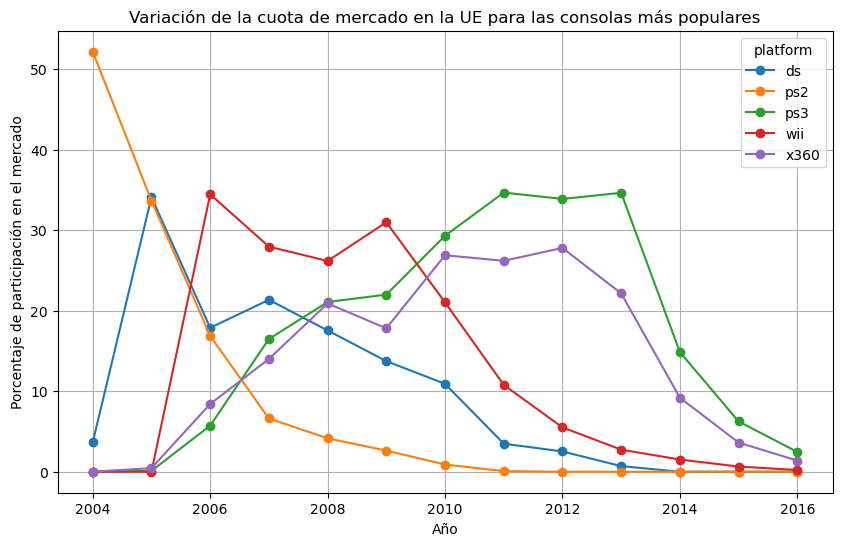

In [24]:
#Agrupamos por año y luego obtenemos la sumatoria de ventas totales para cada año en la UE
ventas_anuales_eu = df_juegos_modernos.groupby('year_of_release')['eu_sales'].sum()
print(ventas_anuales_eu)
#Agrupamos por consola y analizamos las ventas en UE para determinar las 5 consolas populares
ventas_eu_consolas = df_juegos_modernos.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
print(ventas_eu_consolas)
print()
#Creamos un dataset de las 5 plataformas mas populares en la UE
lista_populares_eu = ['ps3','x360','wii','ds','ps2']
filas_condicion_eu = df_juegos_modernos['platform'].isin(lista_populares_eu)
columnas_interes_eu = ['name','platform','year_of_release','eu_sales']
consolas_populares_eu = df_juegos_modernos.loc[filas_condicion_eu,columnas_interes_eu]
print(consolas_populares_eu)
print()
#Creamos una tabla dinámica que muestre por año la variación de la cuota de mercado de cada consola popular en la UE
ventas_ano_consola_eu = consolas_populares_eu.pivot_table(index='year_of_release',columns='platform',values='eu_sales',aggfunc='sum').fillna(0)
cuota_mercado_eu = ventas_ano_consola_eu.div(ventas_anuales_eu,axis=0)*100
print(cuota_mercado_eu)
#Gráficamos la variación año a año de la participación en el mercado para cada consola popular
cuota_mercado_eu.plot(title='Variación de la cuota de mercado en la UE para las consolas más populares',xlabel='Año',ylabel='Porcentaje de participación en el mercado',kind='line',grid=True,figsize=(10,6),marker='o')
plt.show()

En comparación a NA, la UE tuvo un comportamiento similar. Sin embargo, el factor diferenciador es el cambio en las plataformas dominantes.

En 2004, la ps2 inició con un dominio total en Europa, superando el 52% del mercado (casi 10 puntos más que en NA). Aunque, la difrencia radical está en la ps3: a diferencia de NA, en Europa la ps3 se convirtió en la reina indiscutible de su generación. Luego de su lanzamiento, escaló de forma constante hasta estabilizarse en la cima entre 2011 y 2013, reteniendo una cuota máxima cercana al 35%.

La Xbox 360 tuvo un desempeño saludable en Europa, alcanzando su pico en 2012 con un 28%, pero se mantuvo durante todo el ciclo de vida por debajo de la consola de ps3.

La Wii replicó su éxito global con un pico explosivo en 2006 (35% aprox), pero sufrió una pérdida de interés mucho más acelerada a partir de 2010.

year_of_release
2004    41.94
2005    54.29
2006    73.89
2007    60.29
2008    61.28
2009    61.90
2010    59.58
2011    53.09
2012    51.80
2013    47.93
2014    39.69
2015    34.09
2016    19.31
Name: jp_sales, dtype: float64
platform
ds      175.00
3ds     100.62
ps3      79.52
psp      76.38
ps2      70.30
wii      69.05
psv      21.84
gba      18.30
ps4      15.96
wiiu     13.01
x360     12.33
gc        5.78
xone      0.34
n64       0.29
xb        0.22
pc        0.08
dc        0.06
Name: jp_sales, dtype: float64

                                       name platform  year_of_release  \
6263          final fantasy x international      ps2             2004   
7544           pitfall: the lost expedition      ps2             2004   
6942            karaoke revolution volume 2      ps2             2004   
6896                shadow hearts: covenant      ps2             2004   
6282                            athens 2004      ps2             2004   
...                                  

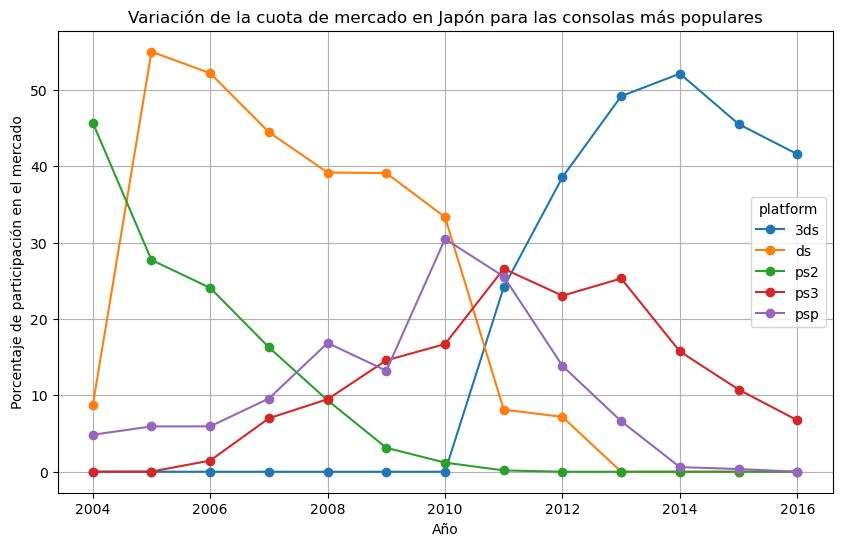

In [25]:
#Agrupamos por año y luego obtenemos la sumatoria de ventas totales para cada año en Japón
ventas_anuales_jp = df_juegos_modernos.groupby('year_of_release')['jp_sales'].sum()
print(ventas_anuales_jp)
#Agrupamos por consola y analizamos las ventas en Japón para determinar las 5 consolas populares
ventas_jp_consolas = df_juegos_modernos.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
print(ventas_jp_consolas)
print()
#Creamos un dataset de las 5 plataformas mas populares en Japón
lista_populares_jp = ['ds','3ds','ps3','psp','ps2']
filas_condicion_jp = df_juegos_modernos['platform'].isin(lista_populares_jp)
columnas_interes_jp = ['name','platform','year_of_release','jp_sales']
consolas_populares_jp = df_juegos_modernos.loc[filas_condicion_jp,columnas_interes_jp]
print(consolas_populares_jp)
print()
#Creamos una tabla dinámica que muestre por año la variación de la cuota de mercado de cada consola popular en Japón
ventas_ano_consola_jp = consolas_populares_jp.pivot_table(index='year_of_release',columns='platform',values='jp_sales',aggfunc='sum').fillna(0)
cuota_mercado_jp = ventas_ano_consola_jp.div(ventas_anuales_jp,axis=0)*100
print(cuota_mercado_jp)
#Gráficamos la variación año a año de la participación en el mercado para cada consola popular
cuota_mercado_jp.plot(title='Variación de la cuota de mercado en Japón para las consolas más populares',xlabel='Año',ylabel='Porcentaje de participación en el mercado',kind='line',grid=True,figsize=(10,6),marker='o')
plt.show()

El mercado japonés no sigue las mismas tendencias que los mercados occidentales; podría decirse que sus picos de ventas y preferencias tecnológicas están fuertemente condicionados por factores culturales específicos.

A diferencia de NA y UE, donde las consolas domésticas de sobremesa competían por el primer lugar, en Japón las nintendo ds y 3ds  destruyeron por completo a la competencia. Lo anterior significa que en Japón existe una gran preferencia por las consolas portatiles. En 2005, la nintendo ds alcanzó una cuota de mercado superior al 55%. Se mantuvo en la cima de la industria durante más de 6 años, demostrando la inmensa preferencia del público japonés por el juego portátil. Tendencia que luego continuó con el relevo generacional hacia la 3ds. Consola que, para 2014, alcanzó un enorme éxito con más del 50% de participación en el mercado nipón. Se ilustra que la etapa de maduración y éxito de la 3ds coincide con la desaparición parcial del mercado de la nintendo ds. Además, continuando con el análisis de consolas portatiles, se exhibe que hasta 2010 la segunda mayor participación en el mercado corresponde a la psp, alcando su mayor cuota (31%) en dicho año. Su pico en participación coincide con la etapa de declive comercial de la nintendo ds.

El gusto del mercado japones por las consolas poratiles es tan grande que una sola consola (nintendo 3ds) llegó a concentrar más de la mitad de todo el dinero de la industria de videojuegos.

La ps3 heredó lentamente el mercado de la ps2, pero tuvo un crecimiento lento. Su punto más alto llegó en 2011 y 2013 con cerca del 26% de participación en el mercado, consolidándose como la consola de sobremesa preferida por los japoneses. No obstante, nunca pudo superar en su etapa de mayor éxito los números de las consolas de nintendo en sus mejores epocas.

Finalmente, sabiendo que las consolas de sobremesa no son las preferidas por los japoneses, es interesante ver como la consola occidental (Xbox 360) no entra ni siquiera en el top 10 de plataformas populares en este mercado, como si lo llega a ser la nintendo Wii. Esto muestra una alta preferencia y confianza en Japón por los productos locales en materia de videojuegos. 

genre
action          628.30
sports          474.66
shooter         434.07
misc            329.64
role-playing    233.49
racing          185.81
platform        176.03
simulation      133.14
fighting        115.15
adventure        71.52
puzzle           53.42
strategy         34.22
Name: na_sales, dtype: float64
genre
action          394.49
sports          281.44
shooter         263.01
misc            176.72
racing          141.79
role-playing    132.31
platform         98.94
simulation       89.60
fighting         51.36
adventure        42.08
puzzle           35.33
strategy         27.31
Name: eu_sales, dtype: float64
genre
role-playing    193.58
action          113.22
misc             75.94
sports           57.20
platform         42.43
fighting         33.02
simulation       32.91
adventure        31.50
shooter          21.34
puzzle           21.19
racing           19.57
strategy         17.18
Name: jp_sales, dtype: float64


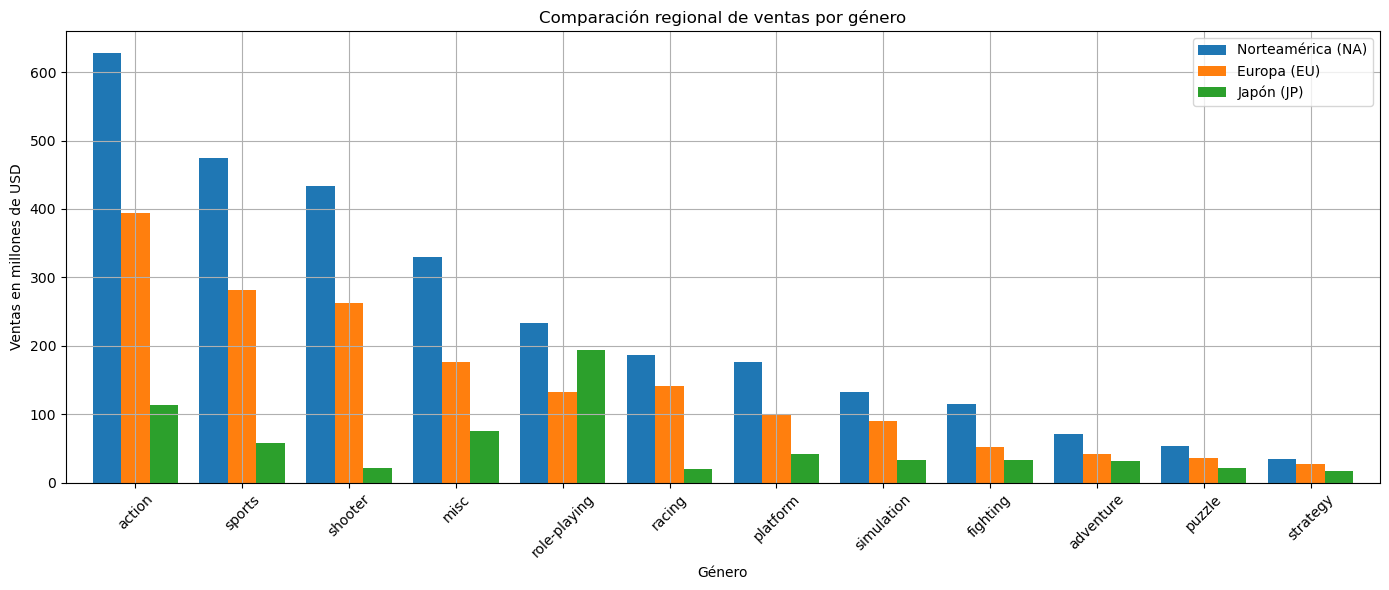

In [27]:
#Observamos primer cuales son los 5 generos más populares por región
ventas_genero_na = df_juegos_modernos.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
ventas_genero_eu = df_juegos_modernos.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
ventas_genero_jp = df_juegos_modernos.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
print(ventas_genero_na)
print(ventas_genero_eu)
print(ventas_genero_jp)

#Agrupamos por genero y luego obtenemos la sumatoria de ventas totales para cada región
ventas_genero = df_juegos_modernos.groupby('genre')[['na_sales','eu_sales','jp_sales']].sum()
#Creamos una columna temporal para organizar los valores
ventas_genero['total_temporal'] = ventas_genero.sum(axis=1)
ventas_genero = ventas_genero.sort_values(by='total_temporal',ascending=False)
ventas_genero = ventas_genero.drop(columns='total_temporal')
#Graficamos las regiones juntas para comparar
ventas_genero.plot(kind='bar',figsize=(14, 6),width=0.8,grid=True,title='Comparación regional de ventas por género',xlabel='Género',ylabel='Ventas en millones de USD')
plt.legend(['Norteamérica (NA)','Europa (EU)','Japón (JP)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Al comparar el comportamiento de ventas por género en las 3 grandes regiones, se puede observar lo siguiente:

El género acción es el rey indiscutible del mercado global. Es el género con mayor recaudación en NA y la UE. Lo interesante es que también mantiene un volumen muy bueno en Japón, demostrando ser el género con mayor transversalidad cultural.

Los géneros deportes y shooter muestran un comportamiento de espejo entre NA y la UE. En ambas regiones ocupan el segundo y tercer lugar de ventas, respectivamente. El jugador occidental parece preferir experiencias competitivas y de ritmo acelerado en consolas grandes.

Al observar el género RPG, la gráfica muestra una anomalía interesante; en todos los géneros anteriores la barra verde de Japón se mantiene pequeña en comparación con las occidentales, mientras que en el RPG ocurre los contario. Japón no solo duplica las ventas de Europa, sino que se encuentra muy cerca de alcanzar el volumen total de NA. Esto demuestra que el RPG es el núcleo cultural y el motor comercial del mercado de videojuegos japonés.

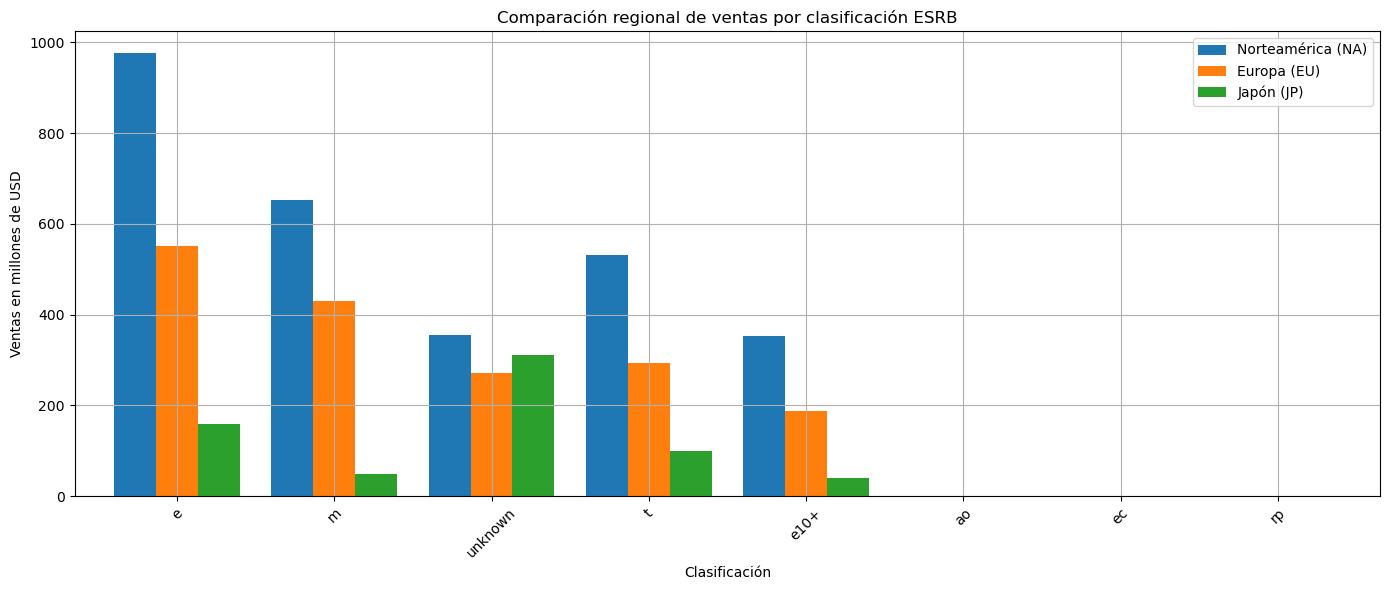

In [28]:
#Agrupamos por rating y luego obtenemos la sumatoria de ventas totales para cada región
ventas_por_rating = df_juegos_modernos.groupby('rating')[['na_sales','eu_sales','jp_sales']].sum()
#Creamos una columna temporal para organizar los valores
ventas_por_rating['total_temporal'] = ventas_por_rating.sum(axis=1)
ventas_por_rating = ventas_por_rating.sort_values(by='total_temporal',ascending=False)
ventas_por_rating = ventas_por_rating.drop(columns='total_temporal')
#Graficamos las regiones juntas para comparar
ventas_por_rating.plot(kind='bar',figsize=(14, 6),width=0.8,grid=True,title='Comparación regional de ventas por clasificación ESRB',xlabel='Clasificación',ylabel='Ventas en millones de USD')
plt.legend(['Norteamérica (NA)','Europa (EU)','Japón (JP)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La región cccidental apuesta por los extremos (E y M). La clasificación E (Todo Público) es el líder en ventas tanto en NA como en Europa. Esto tiene todo el sentido porque, en base a lo demostrado anteriormente, aquí se agrupan los grandes juegos de deportes (como FIFA) y las franquicias familiares masivas de nintendo (como Mario Kart o Wii Sports), que capturan la mayor base posible de ususarios. Tambipen, la llasificación M (Maduro / +17)es la segunda elección más popular en occidente. A pesar de tener un público restringido por edad, los videojuegos de disparos y acción intensa (como Call of Duty) generan ventas masivas.

Por otro lado, al mirar la categoría Unknown (Sin clasificación), se observa que es la única categoría donde Japón supera a Europa y casi alcanza a NA, convirtiéndose en el segmento más rentable para el mercado japonés. Esto no significa que en Japón se vendan juegos sin clasificar. La ESRB es una entidad de clasificación estrictamente norteamericana. Muchos juegos desarrollados y consumidos en Japón son evaluados por su propia entidad local, la CERO (Computer Entertainment Rating Organization). Al no pasar por el proceso de la ESRB, se puede entender por qué en el dataset quedan establecidos como NaN o Unknown. Esto puede demostrar, empíricamente, el inmenso volumen de juegos con dinámicas puramente locales que consume Japón.

Finalmente, mientras que en occidente los juegos clasificación M mueven millones, en Japón la barra verde es sumamente pequeña. El usuario japonés, al tener una fuerte preferencia hacia las consolas portátiles y los RPGs de estética anime, consume más juegos que en NA equivaldrían a clasificaciones E o T (Adolescentes), alejándose de la violencia.

Se ha podido observar entonces que Japón es una región diametralmente diferennte a occidente. Los factores culturales afectan de manera directa la venta y preferencia de videojuegos y consolas. Esto es realmente importante para considerar, ya que da guía para formular campañas de marketing diferenciadas por región, haciendo enfasis en la promoción de ciertas consolas y géneros más que en otras dependiendo de la zona.

Ahora que se ha observado el perfil de consumo y preferencias de las 3 grandes regiones en análisis, se procederá a realizar pruebas de hipótesis independientes para determinar la igualdad o diferencia significativa entre las calificaciones de los usuarios por plataforma y género.

## PASO 5.PRUEBAS DE HIPÓTESIS ESTADÍSTICA

Lo primero será probrar si las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. Para ello, aplicaremos una pruba de hipótesis de dos colas y una prueba de Welch. Esto es porque, como se ha observadi en pasos anteriores, el mercado de PC es muy diferente al de la Xbox One y, por tanto, el tamaño de la muestra para ambas poblaciones es distinta, así como su varianza. Se han escogido estas dos plataformas como ejemplo ya que, como se explicó en pasos anteriores, ambas pertenecen a las consolas denominadas como rentables para el 2017.

La hipótesis nula (H0) es entonces: "Las calificaciones promedio de los ususarios para las plataformas Xbox One y PC son las mismas"; es decir, nada cambia. En contraposición la hipótesis alternativa (Ha) es: "Las calificaciones promedio de los ususarios para las plataformas Xbox One y PC son diferentes". 

Se escoge un nivel de significancia alpha de 0.05. Este número representa el estándar de la industria para estudios de comportamiento de consumidores, garantizando un nivel de confianza del 95% en los resultados obtenidos.

In [29]:
#Filtramos el dataset para obtener solo los juegos de Xbox One y PC y sus calificaciones
calififcaciones_xone = df_juegos_modernos[(df_juegos_modernos['platform']=='xone')&(df_juegos_modernos['user_score'].notna())]['user_score']
calififcaciones_pc = df_juegos_modernos[(df_juegos_modernos['platform']=='pc')&(df_juegos_modernos['user_score'].notna())]['user_score']
#Luego obtenemos los promedios para cada muestra en análisis
promedio_xone = calififcaciones_xone.mean()
promedio_pc = calififcaciones_pc.mean()
print(f'La calificación promedio de los ususarios, en el periodo de análisis, para la Xbox One es {promedio_xone:.2f}')
print(f'La calificación promedio de los ususarios, en el periodo de análisis, para la PC es {promedio_pc:.2f}')
print()
#Ejecutamos la prueba de Welch con el argumento equal_var=False
alpha = 0.05
resultado_xone_pc = st.ttest_ind(calififcaciones_xone,calififcaciones_pc,equal_var=False)
print('p-value =',resultado_xone_pc.pvalue)
print()
if resultado_xone_pc.pvalue<alpha:
    print('Se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para la Xbox One y la PC son distintos')
else:
     print('No se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para la Xbox One y la PC son (virtualmente) iguales')

La calificación promedio de los ususarios, en el periodo de análisis, para la Xbox One es 6.52
La calificación promedio de los ususarios, en el periodo de análisis, para la PC es 6.92

p-value = 0.0007153773042732534

Se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para la Xbox One y la PC son distintos


Se pudo demostrar en la prueba anterior que se cuenta con evidencia estadística suficiente para mostrar que el promedio de calififcación de los usuarios de la Xbox One respecto a la PC es diferente. Esto puede sugerir que los usuarios de ambas plataformas evalúan de forma distinta el catálogo de videojuegos, siendo la comunidad de PC un poco más generosa en sus puntuaciones promedio durante el periodo de análisis.

También se procederá a evaluar estadísticamente si las calificaciones promedio de los ususarios son diferentes en base al genero de los videojuegos. En este caso, se compararán dos generos que lideran el mercado en las 3 principales regiones, especialmente en occidente: Acción y Deportes (esto fue ilustrado en pasos anteriores).

Se formula entonces la hipótesis nula (H0): "Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales"; es decir, nada cambia. Por otro lado, la hipótesis alternativa (Ha) es: "Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes".

La selección del valor alpha = 0.05 se explicó anteriormente.

In [30]:
#Filtramos el dataset para obtener solo los juegos de Acción y Deportes y sus calificaciones
calififcaciones_accion = df_juegos_modernos[(df_juegos_modernos['genre']=='action')&(df_juegos_modernos['user_score'].notna())]['user_score']
calififcaciones_deportes = df_juegos_modernos[(df_juegos_modernos['genre']=='sports')&(df_juegos_modernos['user_score'].notna())]['user_score']
#Luego obtenemos los promedios para cada muestra en análisis
promedio_accion = calififcaciones_accion.mean()
promedio_deportes = calififcaciones_deportes.mean()
print(f'La calificación promedio de los ususarios, en el periodo de análisis, para el género acción es {promedio_accion:.2f}')
print(f'La calificación promedio de los ususarios, en el periodo de análisis, para el género deportes es {promedio_deportes:.2f}')
print()
#Ejecutamos la prueba de Welch con el argumento equal_var=False
alpha = 0.05
resultado_accion_deportes = st.ttest_ind(calififcaciones_accion,calififcaciones_deportes,equal_var=False)
print('p-value =',resultado_accion_deportes.pvalue)
print()
if resultado_accion_deportes.pvalue<alpha:
    print('Se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para los generos acción y deportes son distintos')
else:
     print('No se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para los generos acción y dep son (virtualmente) iguales')


La calificación promedio de los ususarios, en el periodo de análisis, para el género acción es 6.98
La calificación promedio de los ususarios, en el periodo de análisis, para el género deportes es 6.67

p-value = 3.83684039286489e-06

Se rechaza la hipótesis nula (H0). Los promedios de las calificaciones de usuarios para los generos acción y deportes son distintos


Se ha podido evidenciar que se cuenta con evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes. Este comportamiento puede ser debido a la naturaleza de los juegos; mientras que el género de acción ofrece experiencias más variadas e historias diferentes, el género de deportes está dominado por franquicias de lanzamiento anual (como FIFA), las cuales suelen recibir críticas más duras por parte de los usuarios, debido a la percepción de falta de innovación año tras año.

## PASO 6. CONCLUSIÓN GENERAL.

Se ha podido observar el comportamiento general de los videjuegos, analizados por genero, consola, región de venta y clasificaciones.

Lo primero a considerar es que las consolas cuentan con un tiempo de vida de 9 a 11 años aproximadamente. Por tanto, consolas como la PS4 o la Xbox One, aquellas que entraron 'tarde' a este dataset, son aquellas que apenas estan empezando su ciclo de maduración y es importante entonces enfocar campañas que aumenten de manera significativa las ventas de estas a 2017.

En línea con lo anterior, la PC es una plataformas que siempre estará ppresente. Así, campañas enfocadas en promover el uso de la PC como consola de juegos deben apuntar sobretodo a la actualización de motores gráficos de ultima generación que compitan con la PS4 y la Xbox One. Si bien una PC no compita con estas consolas en terminos de ventas, su caracter de ciclo de vida permanente hace que siempre se deba considerar la PC.

Es importante entonces concluir que, una campaña de promoción de consolas y videjuegos para 2017 no solo debe tener en cuenta el ciclo de vida de la consola, sino también a que región va dirigida la campaña. Al demostrar que los factores culturales alteran las ventas por región en base al tipo de consola y genéro, no será lo mismo promover la Xbox One en occidente que en oriente. Las campañas deben ser personalizadas por región.

Finalmente, a manera de consideración para análisis futuros, sería interesante observar más hipótesis estadísticas y análisis que consideren otros factores, como por ejemplo, rangos etarios (si es posible obtener esta información de otras bases de datos). Así mismo, considerar la comparación y comportamiento de las ventas en otras regiones. Hoy día se tiene mucha más información de regiones como LATAM o África. Regiones que historicamente se han sentido relegadas de eventos exclusivos de marcas de consolas y videjuegos pero que pueden representar un mercado muy luc